# Dự đoán doanh số cửa hàng - Store Sales Forecasting

Notebook này sử dụng bộ dữ liệu mới trong `data/new_data` để dự đoán `sales` theo từng ngày, cửa hàng và nhóm sản phẩm.

Quy trình thực hiện:

| Bước | Nội dung |
| --- | --- |
| Bước 0 | Xác định bài toán và chiến lược đánh giá |
| Bước 1 | Đọc dữ liệu mới và kiểm tra schema |
| Bước 2 | EDA tổng quan: target, zero sales, family, thời gian, promotion |
| Bước 3 | Tạo đặc trưng thời gian, store, holiday, oil và lag/rolling sales |
| Bước 4 | Tạo tập train/validation theo thời gian |
| Bước 5 | Xây dựng metric và preprocessing pipeline |
| Bước 6 | So sánh baseline time-series |
| Bước 7 | Huấn luyện và so sánh mô hình ML |
| Bước 8 | Chẩn đoán mô hình bằng biểu đồ trong notebook |
| Bước 9 | Train final model và tạo bảng submission trong notebook |
| Bước 10 | Tổng kết kết quả và hướng cải thiện |

## Bước 0. Xác định bài toán

Mục tiêu là dự đoán doanh số `sales` cho từng tổ hợp:

```text
date × store_nbr × family
```

- Loại bài toán: time-series regression / demand forecasting.
- Biến mục tiêu: `sales`.
- Chỉ số đánh giá chính: RMSLE.
- Chỉ số phụ: MAE, RMSE, R2.
- Chiến lược validation: 16 ngày cuối của tập train, cùng độ dài với `test.csv`.

Điểm quan trọng: các đặc trưng lag/rolling phải được dịch ít nhất 16 ngày để không dùng doanh số của chính giai đoạn cần dự đoán.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "new_data"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
STORES_PATH = DATA_DIR / "stores.csv"
OIL_PATH = DATA_DIR / "oil.csv"
HOLIDAYS_PATH = DATA_DIR / "holidays_events.csv"
TRANSACTIONS_PATH = DATA_DIR / "transactions.csv"

TARGET = "sales"
DATE_COLUMN = "date"
VALIDATION_DAYS = 16
RECENT_TRAIN_DAYS = 365
RANDOM_STATE = 42

## Bước 1. Đọc dữ liệu

Bộ dữ liệu gồm các bảng chính:

- `train.csv`: doanh số lịch sử theo ngày, cửa hàng và nhóm sản phẩm.
- `test.csv`: horizon cần dự đoán.
- `stores.csv`: thông tin cửa hàng.
- `oil.csv`: giá dầu theo ngày.
- `holidays_events.csv`: ngày lễ/sự kiện.
- `transactions.csv`: số giao dịch theo cửa hàng/ngày, dùng cho EDA tham khảo.

In [3]:
train = pd.read_csv(TRAIN_PATH, parse_dates=[DATE_COLUMN])
test = pd.read_csv(TEST_PATH, parse_dates=[DATE_COLUMN])
stores = pd.read_csv(STORES_PATH)
oil = pd.read_csv(OIL_PATH, parse_dates=[DATE_COLUMN])
holidays = pd.read_csv(HOLIDAYS_PATH, parse_dates=[DATE_COLUMN])
transactions = pd.read_csv(TRANSACTIONS_PATH, parse_dates=[DATE_COLUMN])

summary = {
    "train_rows": len(train),
    "test_rows": len(test),
    "train_date_min": str(train[DATE_COLUMN].min().date()),
    "train_date_max": str(train[DATE_COLUMN].max().date()),
    "test_date_min": str(test[DATE_COLUMN].min().date()),
    "test_date_max": str(test[DATE_COLUMN].max().date()),
    "stores": int(train["store_nbr"].nunique()),
    "families": int(train["family"].nunique()),
}
summary

{'train_rows': 3000888,
 'test_rows': 28512,
 'train_date_min': '2013-01-01',
 'train_date_max': '2017-08-15',
 'test_date_min': '2017-08-16',
 'test_date_max': '2017-08-31',
 'stores': 54,
 'families': 33}

## Bước 2. EDA tổng quan

Phần EDA tập trung vào các câu hỏi:

- `sales` phân phối như thế nào?
- Tỷ lệ `sales = 0` có lớn không?
- Nhóm sản phẩm nào đóng góp doanh số lớn nhất?
- Doanh số thay đổi ra sao theo thời gian?
- Promotion có liên quan tới sales không?

Các biểu đồ được hiển thị trực tiếp trong notebook, không xuất ảnh ra thư mục artifact/report.

,count,mean,std,min,25%,50%,75%,max
sales,"3,000,888.0000",357.7757,"1,101.9977",0.0000,0.0000,11.0000,195.8473,"124,717.0000"
onpromotion,"3,000,888.0000",2.6028,12.2189,0.0000,0.0000,0.0000,0.0000,741.0000


Zero sales share: 0.313


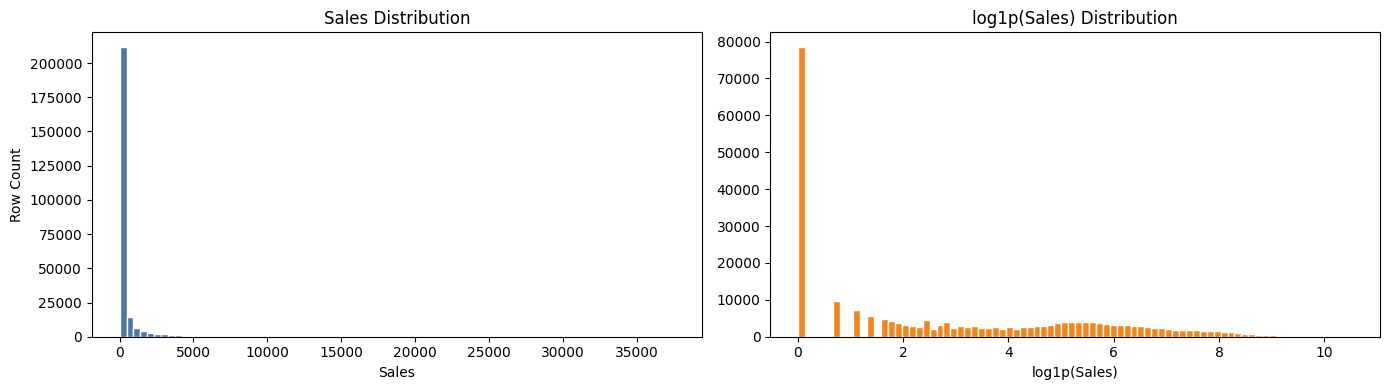

Top families by total sales:


,total_sales
family,
GROCERY I,"343,462,734.8860"
BEVERAGES,"216,954,486.0000"
PRODUCE,"122,704,684.6765"
CLEANING,"97,521,289.0000"
DAIRY,"64,487,709.0000"
BREAD/BAKERY,"42,133,945.5764"
POULTRY,"31,876,004.4717"
MEATS,"31,086,468.4041"
PERSONAL CARE,"24,592,051.0000"


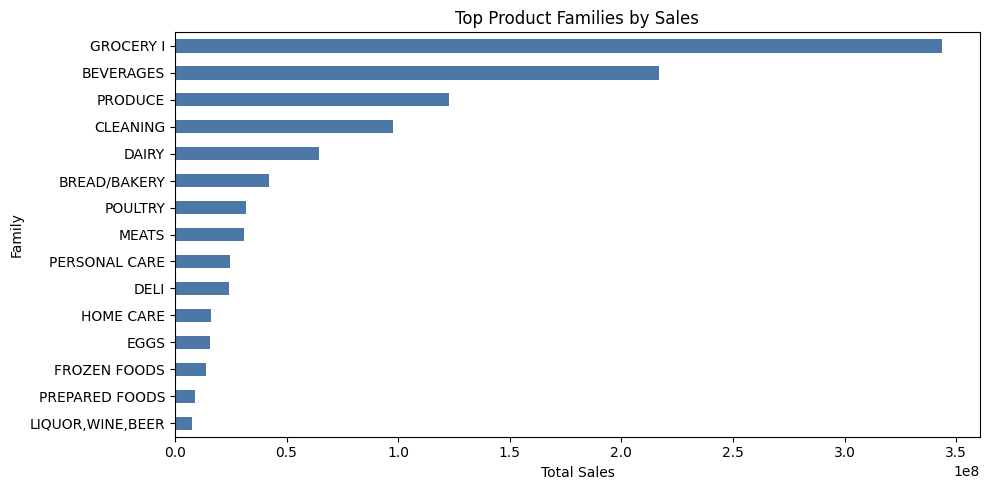

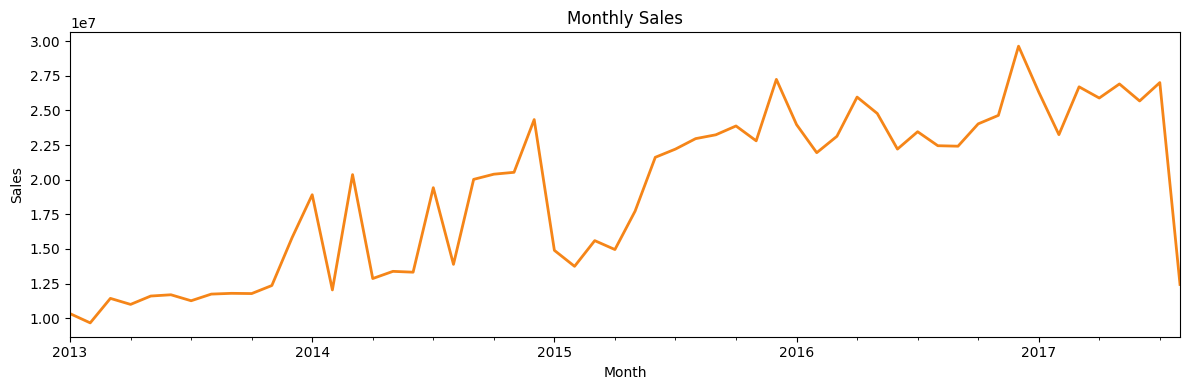

,count,mean,median
promo_bucket,,,
0,2389559,158.2500,3.0000
1-5,355998,645.2600,211.3000
6-20,150471,"1,254.3600",487.8000
20+,104860,"2,642.0700","1,751.0000"


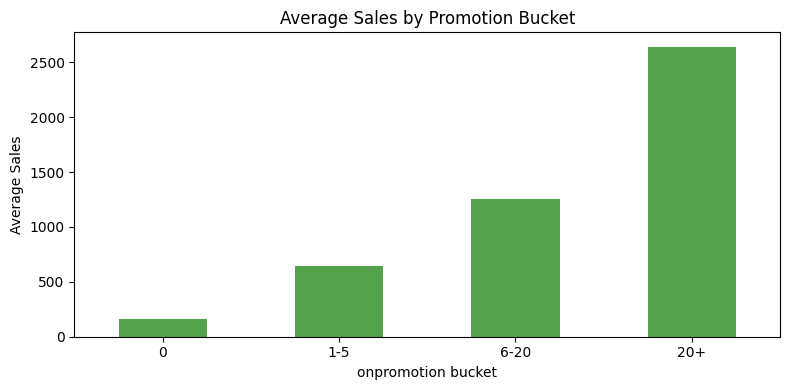

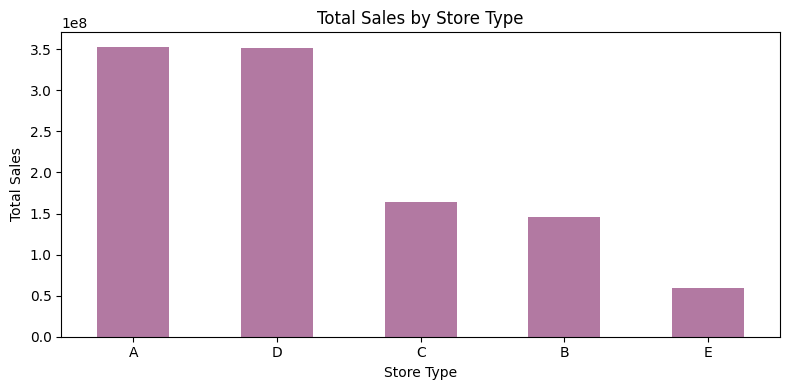

In [4]:
display(train[["sales", "onpromotion"]].describe().T)
print("Zero sales share:", round(float((train[TARGET] == 0).mean()), 4))

sample_sales = train[TARGET].sample(n=min(250_000, len(train)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(sample_sales, bins=80, color="#4c78a8", edgecolor="white")
axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Row Count")
axes[1].hist(np.log1p(sample_sales), bins=80, color="#f58518", edgecolor="white")
axes[1].set_title("log1p(Sales) Distribution")
axes[1].set_xlabel("log1p(Sales)")
fig.tight_layout()
plt.show()

family_sales = train.groupby("family", observed=True)[TARGET].sum().sort_values(ascending=False).head(15)
print("Top families by total sales:")
display(family_sales.to_frame("total_sales"))

fig, ax = plt.subplots(figsize=(10, 5))
family_sales.sort_values().plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_title("Top Product Families by Sales")
ax.set_xlabel("Total Sales")
ax.set_ylabel("Family")
fig.tight_layout()
plt.show()

monthly_sales = train.groupby(pd.Grouper(key=DATE_COLUMN, freq="ME"))[TARGET].sum()
fig, ax = plt.subplots(figsize=(12, 4))
monthly_sales.plot(ax=ax, color="#f58518", linewidth=2)
ax.set_title("Monthly Sales")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
fig.tight_layout()
plt.show()

promo_eda = train.copy()
promo_eda["promo_bucket"] = pd.cut(
    promo_eda["onpromotion"],
    bins=[-1, 0, 5, 20, promo_eda["onpromotion"].max()],
    labels=["0", "1-5", "6-20", "20+"],
)
promo_summary = promo_eda.groupby("promo_bucket", observed=True)[TARGET].agg(["count", "mean", "median"]).round(2)
display(promo_summary)

fig, ax = plt.subplots(figsize=(8, 4))
promo_summary["mean"].plot(kind="bar", ax=ax, color="#54a24b")
ax.set_title("Average Sales by Promotion Bucket")
ax.set_xlabel("onpromotion bucket")
ax.set_ylabel("Average Sales")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

store_sales = train.merge(stores, on="store_nbr", how="left").groupby("type", observed=True)[TARGET].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
store_sales.plot(kind="bar", ax=ax, color="#b279a2")
ax.set_title("Total Sales by Store Type")
ax.set_xlabel("Store Type")
ax.set_ylabel("Total Sales")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

## Bước 3. Tạo đặc trưng

Các nhóm đặc trưng được tạo:

- Đặc trưng lịch: `dayofweek`, `month`, `year`, `dayofmonth`, `is_weekend`.
- Đặc trưng cửa hàng: `city`, `state`, `type`, `cluster`.
- Tín hiệu bên ngoài: giá dầu và holiday/event flags.
- Đặc trưng time-series: `lag_16`, `lag_28`, `lag_364`, rolling mean dịch 16 ngày.

Dịch 16 ngày giúp mô phỏng đúng bài toán dự đoán 16 ngày tương lai mà không nhìn vào doanh số của chính giai đoạn validation/test.

In [5]:
def make_holiday_daily(holidays_df: pd.DataFrame) -> pd.DataFrame:
    active = holidays_df[~holidays_df["transferred"]].copy()
    return (
        active.groupby(DATE_COLUMN)
        .agg(
            is_holiday=("type", lambda values: int((values != "Work Day").any())),
            holiday_count=("type", "size"),
        )
        .reset_index()
    )


def add_calendar_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["dayofweek"] = out[DATE_COLUMN].dt.dayofweek
    out["month"] = out[DATE_COLUMN].dt.month
    out["year"] = out[DATE_COLUMN].dt.year
    out["dayofmonth"] = out[DATE_COLUMN].dt.day
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    return out


def add_lag_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.sort_values(["store_nbr", "family", DATE_COLUMN]).copy()
    grouped_sales = out.groupby(["store_nbr", "family"])[TARGET]
    for lag in [16, 28, 364]:
        out[f"lag_{lag}"] = grouped_sales.shift(lag)
    out["rolling_mean_7_shift16"] = grouped_sales.transform(
        lambda sales: sales.shift(16).rolling(7, min_periods=1).mean()
    )
    out["rolling_mean_28_shift16"] = grouped_sales.transform(
        lambda sales: sales.shift(16).rolling(28, min_periods=1).mean()
    )
    out["rolling_mean_56_shift16"] = grouped_sales.transform(
        lambda sales: sales.shift(16).rolling(56, min_periods=1).mean()
    )
    return out


def build_feature_frame(sales_frame: pd.DataFrame) -> pd.DataFrame:
    oil_clean = oil.sort_values(DATE_COLUMN).copy()
    oil_clean["dcoilwtico"] = oil_clean["dcoilwtico"].ffill().bfill()
    holiday_daily = make_holiday_daily(holidays)

    out = (
        sales_frame.merge(stores, on="store_nbr", how="left")
        .merge(oil_clean, on=DATE_COLUMN, how="left")
        .merge(holiday_daily, on=DATE_COLUMN, how="left")
    )
    out[["is_holiday", "holiday_count"]] = out[["is_holiday", "holiday_count"]].fillna(0)
    out["dcoilwtico"] = out["dcoilwtico"].ffill().bfill()
    out = add_calendar_features(out)
    out = add_lag_features(out)

    lag_columns = [
        "lag_16",
        "lag_28",
        "lag_364",
        "rolling_mean_7_shift16",
        "rolling_mean_28_shift16",
        "rolling_mean_56_shift16",
    ]
    out[lag_columns] = out[lag_columns].fillna(0)
    return out

## Bước 4. Tạo tập train/validation theo thời gian

Validation dùng 16 ngày cuối của `train.csv`, tương ứng đúng forecast horizon trong `test.csv`. Notebook chỉ dùng 365 ngày gần nhất để train nhằm giảm thời gian chạy và ưu tiên tín hiệu gần hiện tại.

In [6]:
feature_frame = build_feature_frame(train)
validation_start = feature_frame[DATE_COLUMN].max() - pd.Timedelta(days=VALIDATION_DAYS - 1)
fit_start = validation_start - pd.Timedelta(days=RECENT_TRAIN_DAYS)

fit_df = feature_frame[
    (feature_frame[DATE_COLUMN] < validation_start)
    & (feature_frame[DATE_COLUMN] >= fit_start)
].copy()
valid_df = feature_frame[feature_frame[DATE_COLUMN] >= validation_start].copy()

print("fit:", fit_df.shape, fit_df[DATE_COLUMN].min().date(), fit_df[DATE_COLUMN].max().date())
print("valid:", valid_df.shape, valid_df[DATE_COLUMN].min().date(), valid_df[DATE_COLUMN].max().date())

fit: (648648, 24) 2016-07-31 2017-07-30
valid: (28512, 24) 2017-07-31 2017-08-15


## Bước 5. Metric và tiền xử lý

RMSLE được chọn vì `sales` không âm và lệch phải. Model được train trên `log1p(sales)`, sau đó chuyển ngược bằng `expm1` để đánh giá trên thang sales gốc.

In [7]:
NUMERIC_FEATURES = [
    "onpromotion",
    "dcoilwtico",
    "dayofweek",
    "month",
    "year",
    "dayofmonth",
    "is_weekend",
    "is_holiday",
    "holiday_count",
    "lag_16",
    "lag_28",
    "lag_364",
    "rolling_mean_7_shift16",
    "rolling_mean_28_shift16",
    "rolling_mean_56_shift16",
]
CATEGORICAL_FEATURES = ["store_nbr", "family", "city", "state", "type", "cluster"]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def rmsle(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> float:
    clipped = np.clip(y_pred, 0, None)
    return float(np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(clipped))))


def sales_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    clipped = np.clip(y_pred, 0, None)
    return {
        "RMSLE": rmsle(y_true, clipped),
        "MAE": float(mean_absolute_error(y_true, clipped)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, clipped))),
        "R2": float(r2_score(y_true, clipped)),
    }


def make_one_hot_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )


def make_ordinal_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "ordinal",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

## Bước 6. Baseline time-series

Với bài forecasting, baseline lag/rolling không phải phụ; đây là đối thủ thật sự. Nếu model ML không thắng baseline này thì model chưa có giá trị thực tế.

In [8]:
baseline_rows = []
for baseline_name, column in {
    "Lag_16": "lag_16",
    "Lag_28": "lag_28",
    "Rolling_Mean_28_Shift16": "rolling_mean_28_shift16",
    "Rolling_Mean_56_Shift16": "rolling_mean_56_shift16",
}.items():
    baseline_rows.append({"model": baseline_name, **sales_metrics(valid_df[TARGET], valid_df[column].to_numpy())})

baseline_df = pd.DataFrame(baseline_rows).sort_values("RMSLE")
display(baseline_df)

,model,RMSLE,MAE,RMSE,R2
3,Rolling_Mean_56_Shift16,0.5457,100.7703,328.1033,0.9309
2,Rolling_Mean_28_Shift16,0.5502,99.0406,322.1254,0.9334
1,Lag_28,0.6274,82.8711,311.2467,0.9378
0,Lag_16,0.6967,145.2255,510.0780,0.8330


## Bước 7. Huấn luyện và đánh giá mô hình

Các mô hình được so sánh:

- Dummy baseline trên log-sales.
- Ridge regression trên one-hot features.
- HistGradientBoosting trên ordinal-encoded categorical features.

Mục tiêu là chọn mô hình có RMSLE thấp nhất trên validation 16 ngày cuối.

In [9]:
x_fit = fit_df[FEATURE_COLUMNS]
y_fit_log = np.log1p(fit_df[TARGET])
x_valid = valid_df[FEATURE_COLUMNS]
y_valid = valid_df[TARGET]

models = {
    "Dummy_Mean_LogSales": Pipeline(
        steps=[("preprocess", make_one_hot_preprocessor()), ("model", DummyRegressor(strategy="mean"))]
    ),
    "Ridge_LogSales": Pipeline(
        steps=[("preprocess", make_one_hot_preprocessor()), ("model", Ridge(alpha=10.0))]
    ),
    "HistGradientBoosting_LogSales_80": Pipeline(
        steps=[
            ("preprocess", make_ordinal_preprocessor()),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=80,
                    learning_rate=0.06,
                    max_leaf_nodes=31,
                    l2_regularization=0.1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "HistGradientBoosting_LogSales_160": Pipeline(
        steps=[
            ("preprocess", make_ordinal_preprocessor()),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=160,
                    learning_rate=0.04,
                    max_leaf_nodes=31,
                    l2_regularization=0.1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

model_rows = []
fitted_models: dict[str, Pipeline] = {}
predictions: dict[str, np.ndarray] = {}
for model_name, pipeline in models.items():
    print(f"Training {model_name}...")
    pipeline.fit(x_fit, y_fit_log)
    pred = np.clip(np.expm1(pipeline.predict(x_valid)), 0, None)
    model_rows.append({"model": model_name, **sales_metrics(y_valid, pred)})
    fitted_models[model_name] = pipeline
    predictions[model_name] = pred

model_df = pd.DataFrame(model_rows).sort_values("RMSLE")
display(model_df)

Training Dummy_Mean_LogSales...
Training Ridge_LogSales...
Training HistGradientBoosting_LogSales_80...
Training HistGradientBoosting_LogSales_160...


,model,RMSLE,MAE,RMSE,R2
3,HistGradientBoosting_LogSales_160,0.4401,74.6214,255.4437,0.9581
2,HistGradientBoosting_LogSales_80,0.4487,76.6636,276.1444,0.9511
1,Ridge_LogSales,0.7982,217.0120,"1,348.0767",-0.1661
0,Dummy_Mean_LogSales,2.5274,460.3286,"1,321.8634",-0.1212


In [10]:
comparison_df = pd.concat([baseline_df, model_df], ignore_index=True).sort_values("RMSLE")
display(comparison_df)

ml_only = model_df[~model_df["model"].str.startswith("Dummy")].copy()
best_row = ml_only.sort_values("RMSLE").iloc[0].to_dict()
best_model_name = best_row["model"]
best_model = fitted_models[best_model_name]
best_valid_pred = predictions[best_model_name]

print("Selected model:", best_model_name)
print(json.dumps({k: round(v, 4) if isinstance(v, float) else v for k, v in best_row.items()}, indent=2))

,model,RMSLE,MAE,RMSE,R2
4,HistGradientBoosting_LogSales_160,0.4401,74.6214,255.4437,0.9581
5,HistGradientBoosting_LogSales_80,0.4487,76.6636,276.1444,0.9511
0,Rolling_Mean_56_Shift16,0.5457,100.7703,328.1033,0.9309
1,Rolling_Mean_28_Shift16,0.5502,99.0406,322.1254,0.9334
2,Lag_28,0.6274,82.8711,311.2467,0.9378
3,Lag_16,0.6967,145.2255,510.0780,0.8330
6,Ridge_LogSales,0.7982,217.0120,"1,348.0767",-0.1661
7,Dummy_Mean_LogSales,2.5274,460.3286,"1,321.8634",-0.1212


Selected model: HistGradientBoosting_LogSales_160
{
  "model": "HistGradientBoosting_LogSales_160",
  "RMSLE": 0.4401,
  "MAE": 74.6214,
  "RMSE": 255.4437,
  "R2": 0.9581
}


## Bước 8. Chẩn đoán mô hình

Các biểu đồ dưới đây được hiển thị trực tiếp trong notebook:

- Actual vs predicted sales.
- Residual distribution.
- MAE theo nhóm sản phẩm.

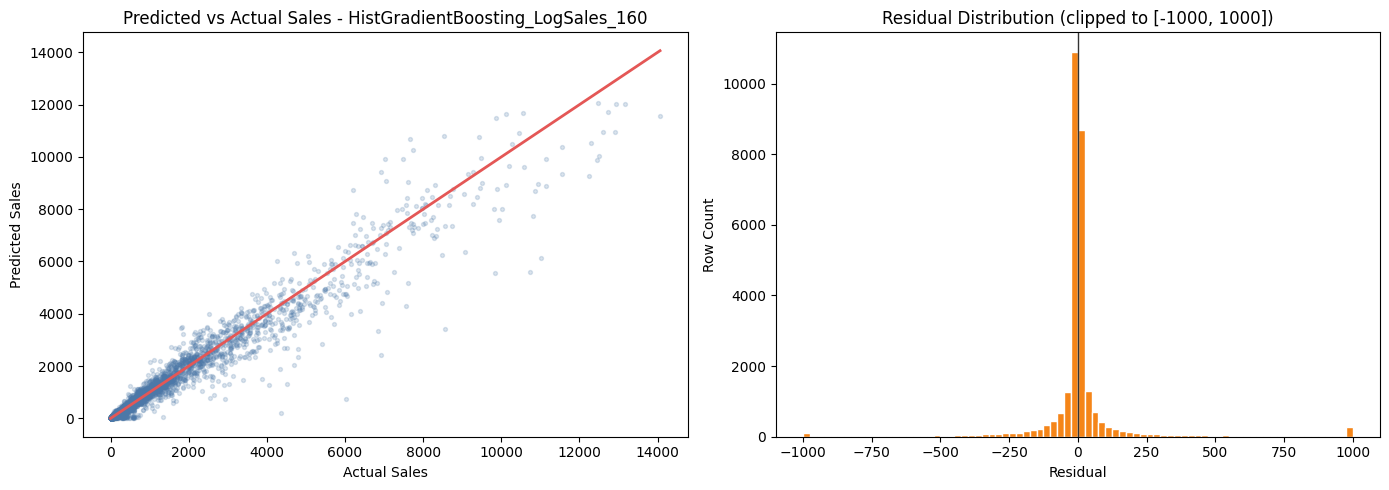

,MAE,sales
family,,
GROCERY I,614.7803,"3,980,412.4840"
BEVERAGES,557.7641,"3,005,407.0000"
PRODUCE,293.7200,"1,977,480.3762"
CLEANING,268.9827,"1,065,243.0000"
DAIRY,122.2257,"721,034.0000"
BREAD/BAKERY,85.5546,"466,795.5009"
MEATS,62.6840,"321,070.5266"
POULTRY,57.1823,"323,560.2689"
HOME CARE,55.0468,"251,893.0000"


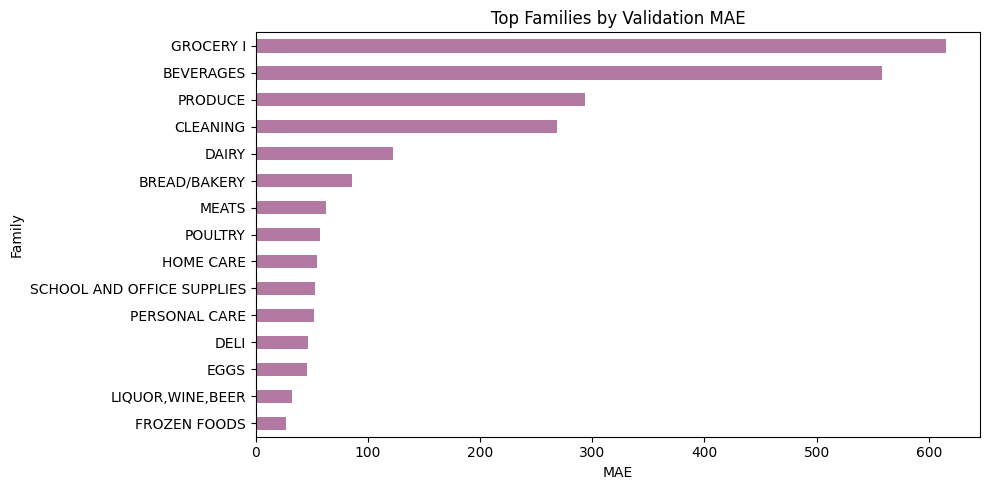

In [11]:
valid_diagnostics = valid_df[["date", "store_nbr", "family", TARGET]].copy()
valid_diagnostics["prediction"] = best_valid_pred
valid_diagnostics["residual"] = valid_diagnostics[TARGET] - valid_diagnostics["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = valid_diagnostics.sample(n=min(12000, len(valid_diagnostics)), random_state=RANDOM_STATE)
axes[0].scatter(sample[TARGET], sample["prediction"], alpha=0.2, s=8, color="#4c78a8")
max_value = max(float(sample[TARGET].max()), float(sample["prediction"].max()))
axes[0].plot([0, max_value], [0, max_value], color="#e45756", linewidth=2)
axes[0].set_title(f"Predicted vs Actual Sales - {best_model_name}")
axes[0].set_xlabel("Actual Sales")
axes[0].set_ylabel("Predicted Sales")

axes[1].hist(valid_diagnostics["residual"].clip(-1000, 1000), bins=80, color="#f58518", edgecolor="white")
axes[1].axvline(0, color="#333333", linewidth=1)
axes[1].set_title("Residual Distribution (clipped to [-1000, 1000])")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Row Count")
fig.tight_layout()
plt.show()

family_error = (
    valid_diagnostics.assign(abs_error=lambda frame: frame["residual"].abs())
    .groupby("family", observed=True)
    .agg(MAE=("abs_error", "mean"), sales=(TARGET, "sum"))
    .sort_values("MAE", ascending=False)
    .head(15)
)
display(family_error)

fig, ax = plt.subplots(figsize=(10, 5))
family_error["MAE"].sort_values().plot(kind="barh", ax=ax, color="#b279a2")
ax.set_title("Top Families by Validation MAE")
ax.set_xlabel("MAE")
ax.set_ylabel("Family")
fig.tight_layout()
plt.show()

## Bước 9. Train final model và tạo submission trong notebook

Cell dưới đây train lại model tốt nhất trên 365 ngày cuối của train và tạo dataframe `submission` cho `test.csv`.

Theo yêu cầu, notebook chỉ tạo dataframe `submission` để xem trực tiếp trong notebook và không tự ghi submission/model/metrics ra `artifacts`.

In [12]:
def build_train_test_feature_frames() -> tuple[pd.DataFrame, pd.DataFrame]:
    train_part = train.copy()
    test_part = test.copy()
    test_part[TARGET] = np.nan
    combined = pd.concat([train_part, test_part], ignore_index=True, sort=False)
    combined_features = build_feature_frame(combined)
    train_features = combined_features[combined_features["id"].isin(train["id"])].copy()
    test_features = combined_features[combined_features["id"].isin(test["id"])].copy()
    return train_features, test_features


full_train_features, test_features = build_train_test_feature_frames()
final_fit_start = full_train_features[DATE_COLUMN].max() - pd.Timedelta(days=RECENT_TRAIN_DAYS)
final_fit_df = full_train_features[full_train_features[DATE_COLUMN] >= final_fit_start].copy()

print("Final fit rows:", final_fit_df.shape)
print("Test feature rows:", test_features.shape)

Final fit rows: (650430, 24)
Test feature rows: (28512, 24)


In [13]:
final_model = models[best_model_name]
final_model.fit(final_fit_df[FEATURE_COLUMNS], np.log1p(final_fit_df[TARGET]))
test_pred = np.clip(np.expm1(final_model.predict(test_features[FEATURE_COLUMNS])), 0, None)

submission = test_features[["id"]].copy()
submission[TARGET] = test_pred
submission = submission.sort_values("id")

display(submission.head())
display(submission[TARGET].describe().to_frame("predicted_sales"))

,id,sales
3000888,3000888,4.1054
3000889,3000889,0.1164
3000890,3000890,5.0141
3000891,3000891,"2,130.5393"
3000892,3000892,0.2315


,predicted_sales
count,"28,512.0000"
mean,438.3388
std,"1,158.8964"
min,0.0000
25%,3.7904
50%,27.5617
75%,260.3531
max,"11,459.3459"


## Bước 10. Tổng kết

Notebook này dùng đúng dạng dữ liệu demand forecasting hơn dataset cũ. Với validation 16 ngày cuối, mô hình HistGradientBoosting trên `log1p(sales)` và các đặc trưng lag/rolling thắng rõ rệt so với baseline time-series.

Các điểm có thể cải thiện tiếp:

- Tuning thêm HistGradientBoosting hoặc dùng LightGBM/XGBoost nếu môi trường cho phép.
- Tạo thêm lag theo mùa vụ như 7, 14, 21, 365 ngày khi bài toán cho phép recursive forecast.
- Xử lý holiday theo `locale` kỹ hơn thay vì gom thành cờ holiday toàn cục.
- Huấn luyện riêng theo nhóm sản phẩm lớn hoặc store cluster nếu muốn tối ưu sâu hơn.